In [ ]:
import numpy as np
import joblib
import xgboost as xgb
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciot2023_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciot2023_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciot2023_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciot2023_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciot2023_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciot2023_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciot2023_class_weights.pkl"))

scale_pos_weight = class_weights[0] / class_weights[1]
print(f"Train: {X_train.shape}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

Training XGBoost...
[0]	validation_0-logloss:0.21170
[50]	validation_0-logloss:0.09385
[100]	validation_0-logloss:0.08766
[150]	validation_0-logloss:0.08350
[199]	validation_0-logloss:0.08059
Done.

Validation:
  F1:        0.9802
  AUC-ROC:   0.9953
  Precision: 0.9620
  Recall:    0.9991
  Accuracy:  0.9616

Test:
  F1:        0.9805
  AUC-ROC:   0.9958
  Precision: 0.9622
  Recall:    0.9994
  Accuracy:  0.9622


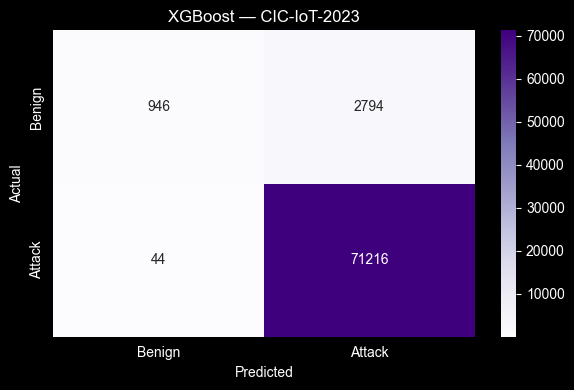

True Negatives:  946
False Positives: 2794
False Negatives: 44
True Positives:  71216

Model saved.


In [2]:
# ── Train XGBoost ─────────────────────────────────────────────────────────
print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=10,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print("Done.")

# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")

evaluate(xgb_model, X_val,  y_val,  "Validation")
evaluate(xgb_model, X_test, y_test, "Test")

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_test = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('XGBoost — CIC-IoT-2023', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_xgboost_confusion_matrix.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

xgb_model.save_model(os.path.join(MODELS, "ciciot2023_xgboost.json"))
print("\nModel saved.")